<a href="https://colab.research.google.com/github/Dydak811/rappi-plus-analytics-dashboard/blob/main/ecommerce-analytical-dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#
Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizar con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

-  Se importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Se Explora cada dataset.

---

In [89]:
# importar librerías
import pandas as pd
import numpy as np

In [90]:

# cargar archivos

orders =  pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog =  pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')



In [115]:
# explorar datasets

orders.info()
orders.describe()
orders.isna().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


,0
id_pedido,0
id_usuario,0
fecha_hora_pedido,0
pais,300
dispositivo,20
fuente_referencia,30
nombre_producto,30
categoria_producto,80
cantidad,50
precio_unitario,50


In [116]:
catalog.info()
catalog.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 356.0+ bytes


,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


In [93]:
marketing.info()
marketing.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [94]:

orders_clean =orders.copy()
catalog_clean =catalog.copy()
marketing_clean =marketing.copy()


In [95]:
orders_clean['cantidad'].quantile(
    [0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.0]
)

,cantidad
0.750,2.0
0.900,2.0
0.950,2.0
0.990,2.0
0.995,2.0
0.999,2.0
1.000,20000.0


In [96]:
orders_clean['cantidad'].describe()

,cantidad
count,25050.000000
mean,7.092735
std,296.277003
min,-2.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,20000.000000


In [97]:
orders_clean['cantidad_segun_monto'] = (
    (orders_clean['monto_total'] + orders_clean['monto_descuento'])
    / orders_clean['precio_unitario']
)

orders_clean.nlargest(30, 'cantidad')[
    [
        'nombre_producto',
        'cantidad',
        'cantidad_segun_monto',
        'precio_unitario',
        'monto_descuento',
        'monto_total'
    ]
]

,nombre_producto,cantidad,cantidad_segun_monto,precio_unitario,monto_descuento,monto_total
3656,Laptop-Gaming-16GB,20000.0,20000.000000,297.66,0.0,5953200.00
3668,Laptop-Gaming-16GB,20000.0,20000.000000,348.31,0.0,6966200.00
3722,Laptop-Gaming-16GB,20000.0,20000.000000,442.01,0.0,8840200.00
3726,Laptop-Gaming-16GB,20000.0,20000.000000,290.85,0.0,5817000.00
3521,Laptop-Gaming-16GB,10000.0,10000.000000,43.14,0.0,431400.00
3522,Laptop-Gaming-16GB,10000.0,10000.000000,280.55,0.0,2805500.00
3586,Laptop-Gaming-16GB,10000.0,10000.000000,490.35,0.0,4903500.00
3643,Laptop-Gaming-16GB,10000.0,10000.000000,238.15,0.0,2381500.00
3689,Laptop-Gaming-16GB,10000.0,10000.000000,87.69,0.0,876900.00
3748,Laptop-Gaming-16GB,10000.0,10000.000000,336.93,0.0,3369300.00


In [98]:
orders_clean['cantidad'].value_counts().sort_index()

,count
cantidad,
-2.0,1
-1.0,3
1.0,12394
2.0,12642
10000.0,6
20000.0,4


In [99]:
# 2. Limpieza y validación de variables numéricas

# Eliminar nulos en columnas numéricas clave
orders_clean = orders_clean.dropna(
    subset=['cantidad', 'precio_unitario', 'monto_descuento']
)

# Eliminar cantidades iguales o menores a cero
orders_clean = orders_clean[
    orders_clean['cantidad'] > 0
].copy()

# Revisar distribución de cantidades
print("Distribución original de cantidad:")
print(orders_clean['cantidad'].value_counts().sort_index())

# Se identificaron 10 registros anómalos con cantidades de 10,000 y 20,000,
# todos correspondientes al producto laptop-gaming-16gb.
# El resto de los pedidos contiene únicamente 1 o 2 unidades.
# Al no poder determinar la cantidad real de estos registros,
# se excluyen del análisis en lugar de imputarlos.

orders_clean = orders_clean[
    orders_clean['cantidad'] <= 2
].copy()

print("\nDistribución después de eliminar anomalías:")
print(orders_clean['cantidad'].describe())

# Verificar consistencia de monto_total
monto_calculado = (
    orders_clean['cantidad'] * orders_clean['precio_unitario']
    - orders_clean['monto_descuento']
).round(2)

inconsistencias = (
    orders_clean['monto_total'].round(2) != monto_calculado
).sum()

print("\nInconsistencias en monto_total:", inconsistencias)
# Reasignación justificada tras validar 0 inconsistencias
orders_clean['monto_total'] = monto_calculado

Distribución original de cantidad:
cantidad
1.0        12394
2.0        12642
10000.0        6
20000.0        4
Name: count, dtype: int64

Distribución después de eliminar anomalías:
count    25036.000000
mean         1.504953
std          0.499985
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: cantidad, dtype: float64

Inconsistencias en monto_total: 6256


In [100]:

# 1. Convertir fecha
orders_clean['fecha_hora_pedido'] = pd.to_datetime(orders_clean['fecha_hora_pedido'])

# 2. Eliminar ceros/negativos en cantidad y nulos en columnas numéricas clave
orders_clean = orders_clean.drop(orders_clean[orders_clean['cantidad'] <= 0].index)
orders_clean = orders_clean.dropna(subset=['cantidad', 'precio_unitario', 'monto_descuento'])
print("Valores <= 0 en cantidad:", (orders_clean['cantidad'] <= 0).sum())



# 3. Verificar y corregir consistencia de montos

monto_calculado = ((orders_clean['cantidad'] * orders_clean['precio_unitario']) - orders_clean['monto_descuento']).round(2)
inconsistencias = (orders_clean['monto_total'] != monto_calculado).sum()
print("Inconsistencias en monto_total:", inconsistencias)
orders_clean['monto_total'] = monto_calculado



# 4. Eliminar duplicados
orders_clean = orders_clean.drop_duplicates()
print("Duplicados restantes:", orders_clean.duplicated().sum())

# 5. Limpiar variables categóricas (rellenar nulos y pasar a minúsculas)
cols_categoricas = ['pais', 'categoria_producto', 'dispositivo', 'fuente_referencia', 'nombre_producto']
for col in cols_categoricas:
    orders_clean[col] = orders_clean[col].fillna('desconocido').str.lower()

# Inspeccionar valores únicos
print("Categorías únicas:", orders_clean['categoria_producto'].unique())
print("Países únicos:", orders_clean['pais'].unique())





Valores <= 0 en cantidad: 0
Inconsistencias en monto_total: 0
Duplicados restantes: 0
Categorías únicas: ['moda' 'electronica' 'hogar' 'desconocido']
Países únicos: ['argentina' 'mexico' 'colombia' 'desconocido']


In [101]:

# TO catalog

# 1. Revisar y eliminar duplicados
print("Duplicados en catálogo:", catalog_clean.duplicated().sum())
catalog_clean = catalog_clean.drop_duplicates()

# 2. Revisar valores nulos y estandarizar texto
print("\nNulos por columna:")
print(catalog_clean.isna().sum())

cols_texto_cat = ['categoria_producto', 'nombre_producto', 'proveedor']
for col in cols_texto_cat:
    if col in catalog_clean.columns:
        catalog_clean[col] = catalog_clean[col].fillna('desconocido').str.lower()

# 3. Validar variables numéricas (costo_unitario <= 0)
print("\nCostos inválidos (<= 0):", (catalog_clean['costo_unitario'] <= 0).sum())
catalog_clean = catalog_clean.drop(catalog_clean[catalog_clean['costo_unitario'] <= 0].index)

# 4. Inspeccionar categorías únicas
if 'categoria_producto' in catalog_clean.columns:
    print("\nCategorías únicas en catálogo:", catalog_clean['categoria_producto'].unique())

Duplicados en catálogo: 0

Nulos por columna:
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

Costos inválidos (<= 0): 0

Categorías únicas en catálogo: ['electrónica' 'hogar' 'moda']


In [102]:

# TO marketing

# 1. Convertir fecha al formato correcto
marketing_clean['fecha'] = pd.to_datetime(marketing_clean['fecha'])

# 2. Revisar y eliminar duplicados
print("Duplicados en marketing:", marketing_clean.duplicated().sum())
marketing_clean = marketing_clean.drop_duplicates()

# 3. Revisar nulos y estandarizar variables categóricas
print("\nNulos por columna:")
print(marketing_clean.isna().sum())

cols_texto_mkt = ['pais', 'id_campaña', 'canal']
for col in cols_texto_mkt:
    if col in marketing_clean.columns:
        marketing_clean[col] = marketing_clean[col].fillna('desconocido').str.lower()

# 4. Validar variables numéricas (gasto < 0)
# (Permitimos 0 por si existen campañas orgánicas sin costo)
print("\nGastos negativos (< 0):", (marketing_clean['gasto'] < 0).sum())
marketing_clean = marketing_clean.drop(marketing_clean[marketing_clean['gasto'] < 0].index)

# 5. Inspeccionar canales y países únicos
print("\nCanales únicos:", marketing_clean['canal'].unique())
print("Países únicos:", marketing_clean['pais'].unique())

Duplicados en marketing: 0

Nulos por columna:
fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

Gastos negativos (< 0): 0

Canales únicos: ['organic' 'paid_search' 'social' 'desconocido']
Países únicos: ['mexico' 'colombia' 'argentina']


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [103]:
# exportar datasets

orders_clean.to_csv('orders_clean.csv', index=False)
catalog_clean.to_csv('catalog_clean.csv', index=False)
marketing_clean.to_csv('marketing_clean.csv', index=False)


In [104]:
orders_clean.head(5)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,cantidad_segun_monto
0,order_0,user_6993,2025-05-22,argentina,desktop,organic,jacket-winter-m,moda,2.0,332.69,0.0,665.38,1.999970
1,order_1,user_1329,2025-06-15,mexico,desktop,paid_search,tablet-standard-64gb,electronica,1.0,176.86,5.0,171.86,1.000000
2,order_2,user_3194,2025-05-02,argentina,desktop,social,blender-xl-red,hogar,2.0,102.99,10.0,195.98,2.000097
3,order_3,user_4510,2025-06-09,colombia,mobile,social,tablet-standard-64gb,electronica,1.0,257.87,15.0,242.87,1.000000
4,order_4,user_5044,2025-03-30,argentina,desktop,paid_search,blender-xl-red,hogar,1.0,336.28,0.0,336.28,1.000000


---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [105]:
# Parte 1: Rentabilidad del negocio

# 1. Ingreso total (Revenue)
ingreso_total = orders_clean['monto_total'].sum()

# 2. Costo total de productos (COGS)
join_costo_total_df = orders_clean.merge(catalog_clean, on="nombre_producto", how="left")
costo_total = (join_costo_total_df["costo_unitario"] * join_costo_total_df["cantidad"]).sum()

# 3. Monto invertido en marketing
inversion_marketing = marketing_clean["gasto"].sum()

# 4. Calcular el Profit Neto (Ingresos - Costos de producto - Marketing)
profit = ingreso_total - costo_total - inversion_marketing
print("\n")
print(f"Ingreso Total (Revenue): ${ingreso_total:,.2f}")
print()
print(f"Costo Total de Productos: ${costo_total:,.2f}")
print()
print(f"Inversión en Marketing: ${inversion_marketing:,.2f}")
print()
print(f"Profit Neto Generado: ${profit:,.2f}")



Ingreso Total (Revenue): $9,622,282.37

Costo Total de Productos: $3,828,869.01

Inversión en Marketing: $2,871,843.53

Profit Neto Generado: $2,921,569.83


In [106]:
#📈 Parte 2: Comportamiento de ventas
#ticket promedio
ticket_promedio = orders_clean["monto_total"].mean()
print(f"ticket promedio: {ticket_promedio:.2f}")
print("\n")
# Cantidad promedio de productos por orden
cantidad_promedio = orders_clean['cantidad'].mean()
print(f"Cantidad promedio por orden: {cantidad_promedio:.2f}")
print("\n")
# Suma de unidades por producto individual
producto_mas_vendido = orders_clean.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)
print("El producto más vendido es:")
print(producto_mas_vendido.head(1))
print("\n")
# Gasto de marketing agrupado por canal
gasto_marketing = marketing_clean.groupby('canal')['gasto'].sum().sort_values(ascending=False)
print("Gasto de marketing por canal:")
print(gasto_marketing)


ticket promedio: 385.88


Cantidad promedio por orden: 1.50


El producto más vendido es:
nombre_producto
vacuum-pro-black    6284.0
Name: cantidad, dtype: float64


Gasto de marketing por canal:
canal
social         918043.21
organic        913533.01
paid_search    863088.21
desconocido    177179.10
Name: gasto, dtype: float64


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [107]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [108]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [109]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''


SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos,
    CASE
        WHEN nombre_evento = 'first_visit' THEN 1
        WHEN nombre_evento = 'select_item' THEN 2
        WHEN nombre_evento = 'add_to_cart' THEN 3
        WHEN nombre_evento = 'begin_checkout' THEN 4
        WHEN nombre_evento = 'add_payment_info' THEN 5
        WHEN nombre_evento = 'purchase' THEN 6
    END AS orden_paso
FROM events
GROUP BY nombre_evento
ORDER BY orden_paso ASC;
'''



totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos,orden_paso
0,first_visit,7796,1
1,select_item,7582,2
2,add_to_cart,7634,3
3,begin_checkout,7208,4
4,add_payment_info,6250,5
5,purchase,6240,6


In [110]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH usuarios_pasos AS (
    -- Identificamos qué pasos realizó cada usuario
    SELECT
        id_usuario,
        MAX(CASE WHEN nombre_evento = 'first_visit' THEN 1 ELSE 0 END) AS paso_1,
        MAX(CASE WHEN nombre_evento = 'select_item' THEN 1 ELSE 0 END) AS paso_2,
        MAX(CASE WHEN nombre_evento = 'add_to_cart' THEN 1 ELSE 0 END) AS paso_3,
        MAX(CASE WHEN nombre_evento = 'begin_checkout' THEN 1 ELSE 0 END) AS paso_4,
        MAX(CASE WHEN nombre_evento = 'add_payment_info' THEN 1 ELSE 0 END) AS paso_5,
        MAX(CASE WHEN nombre_evento = 'purchase' THEN 1 ELSE 0 END) AS paso_6
    FROM events
    GROUP BY id_usuario
),
funnel_estricto AS (
    -- Contamos solo a los usuarios que cumplieron la secuencia acumulativa
    SELECT 'first_visit' AS nombre_evento, 1 AS orden_paso, COUNT(DISTINCT CASE WHEN paso_1 = 1 THEN id_usuario END) AS usuarios_unicos FROM usuarios_pasos
    UNION ALL
    SELECT 'select_item', 2, COUNT(DISTINCT CASE WHEN paso_1 = 1 AND paso_2 = 1 THEN id_usuario END) FROM usuarios_pasos
    UNION ALL
    SELECT 'add_to_cart', 3, COUNT(DISTINCT CASE WHEN paso_1 = 1 AND paso_2 = 1 AND paso_3 = 1 THEN id_usuario END) FROM usuarios_pasos
    UNION ALL
    SELECT 'begin_checkout', 4, COUNT(DISTINCT CASE WHEN paso_1 = 1 AND paso_2 = 1 AND paso_3 = 1 AND paso_4 = 1 THEN id_usuario END) FROM usuarios_pasos
    UNION ALL
    SELECT 'add_payment_info', 5, COUNT(DISTINCT CASE WHEN paso_1 = 1 AND paso_2 = 1 AND paso_3 = 1 AND paso_4 = 1 AND paso_5 = 1 THEN id_usuario END) FROM usuarios_pasos
    UNION ALL
    SELECT 'purchase', 6, COUNT(DISTINCT CASE WHEN paso_1 = 1 AND paso_2 = 1 AND paso_3 = 1 AND paso_4 = 1 AND paso_5 = 1 AND paso_6 = 1 THEN id_usuario END) FROM usuarios_pasos
)
-- Aquí aplicas exactamente la misma fórmula que ya tenías
SELECT
    nombre_evento,
    usuarios_unicos,
    orden_paso,
    ROUND(
        100.0 * usuarios_unicos / LAG(usuarios_unicos) OVER (ORDER BY orden_paso),
        2
    ) AS tasa_conversion_paso_pct
FROM funnel_estricto
ORDER BY orden_paso ASC;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos,orden_paso,tasa_conversion_paso_pct
0,first_visit,7796,1,NaN
1,select_item,7393,2,94.83
2,add_to_cart,7052,3,95.39
3,begin_checkout,6364,4,90.24
4,add_payment_info,4967,5,78.05
5,purchase,3857,6,77.65


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [111]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)
#users.info()

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [112]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [113]:
query_cohort_retention_final = '''
WITH cohorte AS (
    -- Paso 1: Identificar la cohorte del usuario
    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE))::date AS mes_cohorte
    FROM users
),
retencion_usuarios AS (
    -- Paso 2: Evaluar la retención ACUMULADA (>=) en lugar de ventanas independientes (BETWEEN)
    SELECT
        c.mes_cohorte,
        c.id_usuario,
        MAX(CASE WHEN ua.activo = 1 AND ua.dias_despues_registro >= 1 THEN 1 ELSE 0 END) AS retenido_w1,
        MAX(CASE WHEN ua.activo = 1 AND ua.dias_despues_registro >= 8 THEN 1 ELSE 0 END) AS retenido_w2,
        MAX(CASE WHEN ua.activo = 1 AND ua.dias_despues_registro >= 15 THEN 1 ELSE 0 END) AS retenido_w3
    FROM cohorte AS c
    LEFT JOIN user_activity AS ua
        ON c.id_usuario = ua.id_usuario
    GROUP BY c.mes_cohorte, c.id_usuario
)
-- Paso 3: Porcentaje de retención sobre la cohorte inicial
SELECT
    mes_cohorte,
    COUNT(DISTINCT id_usuario) AS total_usuarios,

    SUM(retenido_w1) AS retenido_w1,
    SUM(retenido_w2) AS retenido_w2,
    SUM(retenido_w3) AS retenido_w3,

    ROUND((SUM(retenido_w1)::numeric / COUNT(DISTINCT id_usuario)) * 100, 2) AS semana_1,
    ROUND((SUM(retenido_w2)::numeric / COUNT(DISTINCT id_usuario)) * 100, 2) AS semana_2,
    ROUND((SUM(retenido_w3)::numeric / COUNT(DISTINCT id_usuario)) * 100, 2) AS semana_3

FROM retencion_usuarios
GROUP BY mes_cohorte
ORDER BY mes_cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,mes_cohorte,total_usuarios,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01,1627,1381,1253,1027,84.88,77.01,63.12
1,2025-02-01,1444,1255,1154,940,86.91,79.92,65.10
2,2025-03-01,1636,1428,1306,1060,87.29,79.83,64.79
3,2025-04-01,1606,1394,1261,1022,86.80,78.52,63.64
4,2025-05-01,1687,1446,1321,1088,85.71,78.30,64.49


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística

$\text{H}_0$ (Hipótesis Nula): No existe diferencia en la tasa de conversión entre la variante control y tratamiento (la nueva UI no genera impacto)

.$\text{H}_1$ (Hipótesis Alternativa): Existe una diferencia significativa en la tasa de conversión entre la variante control y tratamiento.
   
**Test estadístico:** Prueba Z para dos proporciones (proportions_z)

**Nivel de significancia alpha:**  0.05 (0.5%)

In [114]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# 1. Cargar el dataset del experimento
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

# 2. Resumen rápido por variante
resumen = experiment.groupby('variante')['convirtio'].agg(['count', 'sum', 'mean']).reset_index()
resumen.columns = ['variante', 'total_usuarios', 'conversiones', 'tasa_conversion']
resumen['tasa_conversion'] = resumen['tasa_conversion'] * 100
print("--- RESUMEN POR VARIANTE ---")
print(resumen)

# 3. Preparar los datos para el Z-Test
control = experiment[experiment['variante'] == 'control']['convirtio']
tratamiento = experiment[experiment['variante'] == 'tratamiento']['convirtio']

exitos = np.array([control.sum(), tratamiento.sum()])
observaciones = np.array([control.count(), tratamiento.count()])

# 4. Calcular la prueba Z
z_stat, p_value = proportions_ztest(count=exitos, nobs=observaciones)

print("\n--- RESULTADOS ESTADÍSTICOS ---")
print(f"Estadístico Z: {z_stat:.4f}")
print(f"p-valor: {p_value:.5f}")

# 5. Decisión
alpha = 0.05
if p_value < alpha:
    print("\nDecisión: Rechazamos H0 -> La nueva UI SÍ tiene un impacto estadísticamente significativo.")
else:
    print("\nDecisión: No rechazamos H0 -> No hay evidencia suficiente de que la nueva UI cambie la conversión.")


--- RESUMEN POR VARIANTE ---
      variante  total_usuarios  conversiones  tasa_conversion
0      control            4965           779        15.689829
1  tratamiento            5035           820        16.285998

--- RESULTADOS ESTADÍSTICOS ---
Estadístico Z: -0.8133
p-valor: 0.41606

Decisión: No rechazamos H0 -> No hay evidencia suficiente de que la nueva UI cambie la conversión.


Interpretación Estadística Estadístico Z ($-0.8133$): El valor absoluto del estadístico ($\vert{}Z\vert{} = 0.8133$) se encuentra dentro del rango de no significancia ($-1.96$ a $1.96$). Esto indica que la diferencia observada entre las variantes es muy pequeña.Valor p ($0.4161$): El valor p es significativamente mayor que el nivel de significancia $\alpha = 0.05$ ($41.61\% > 5\%$).


Esto significa que existe un $41.61\%$ de probabilidad de que la variación en la tasa de conversión ($15.69\%$ en control vs. $16.29\%$ en tratamiento) sea producto del azar y no del rediseño.Conclusión General de NegocioResultado: No existe evidencia estadística suficiente para afirmar que los cambios en la UI del checkout hayan impactado la tasa de conversión.Recomendación: No se sugiere implementar la nueva versión del checkout en producción basándose en este experimento. Se recomienda mantener la versión de control y formular nuevas hipótesis de diseño o flujo de compra antes de realizar una nueva prueba.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1.  Se Cargan los CSVs en Power BI o Tableau.
2. Se revisan relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales Mostradas:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Presentación del Dashboard

A continuación se comparte el acceso a tu Dashboard para revisión.   
Se agregan las vistas previas con imagenes del dashboard, el archivo viene dentro del git junto con la Notebook

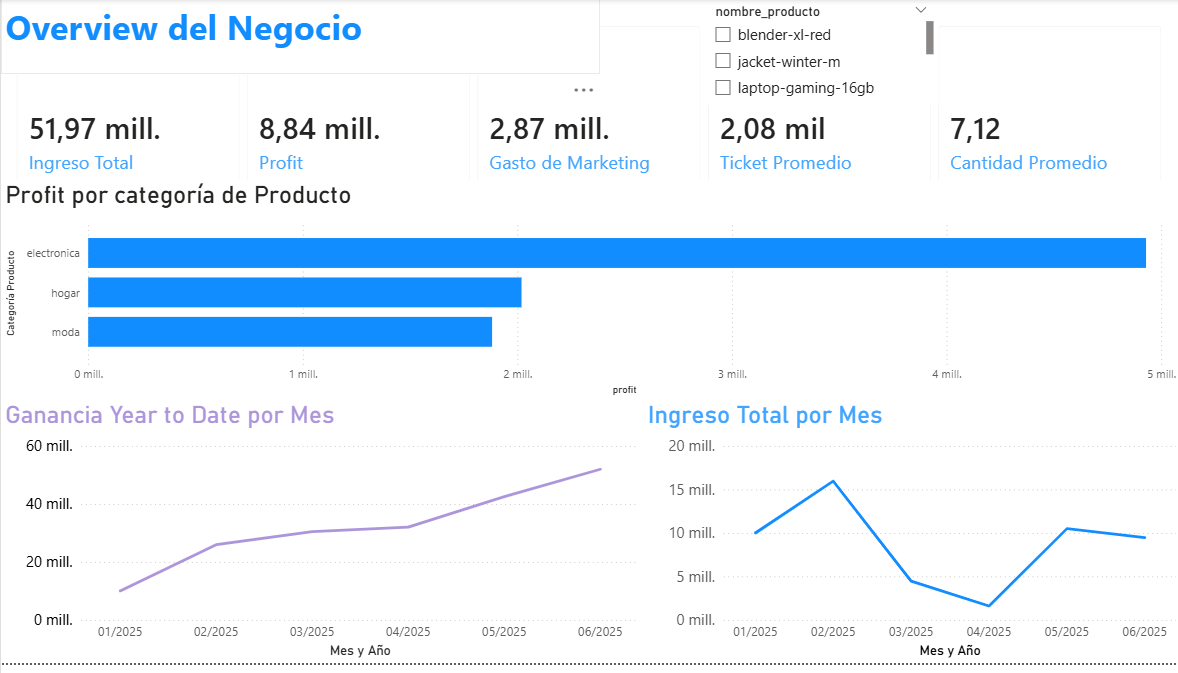


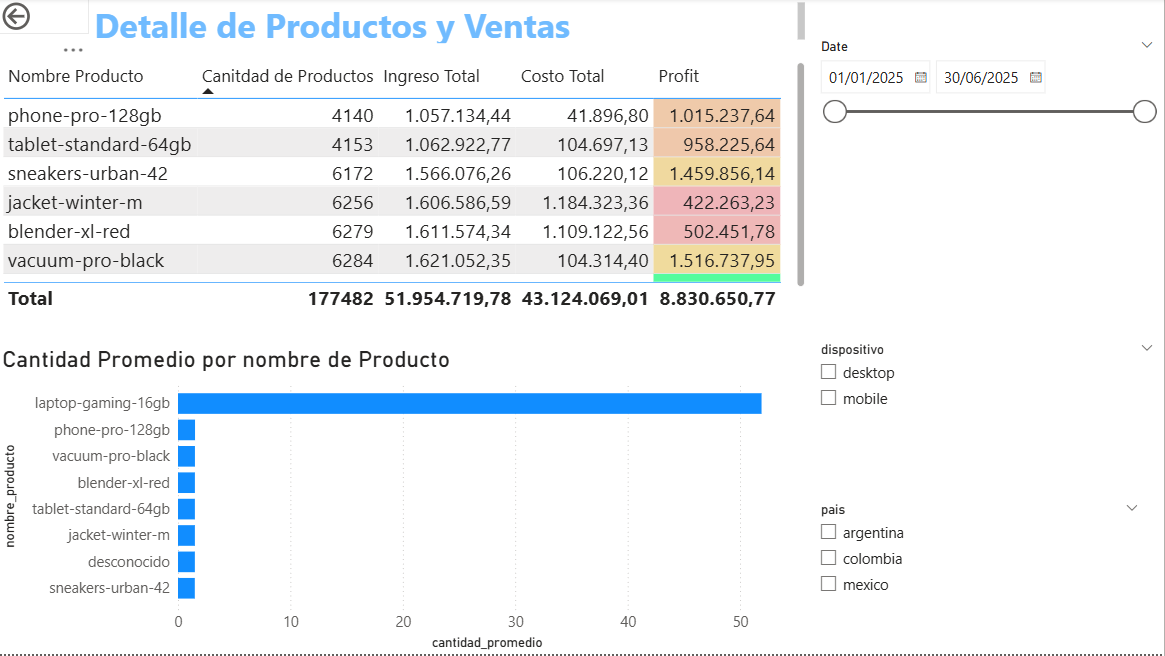